Acá esta el tp con el error que te comenté

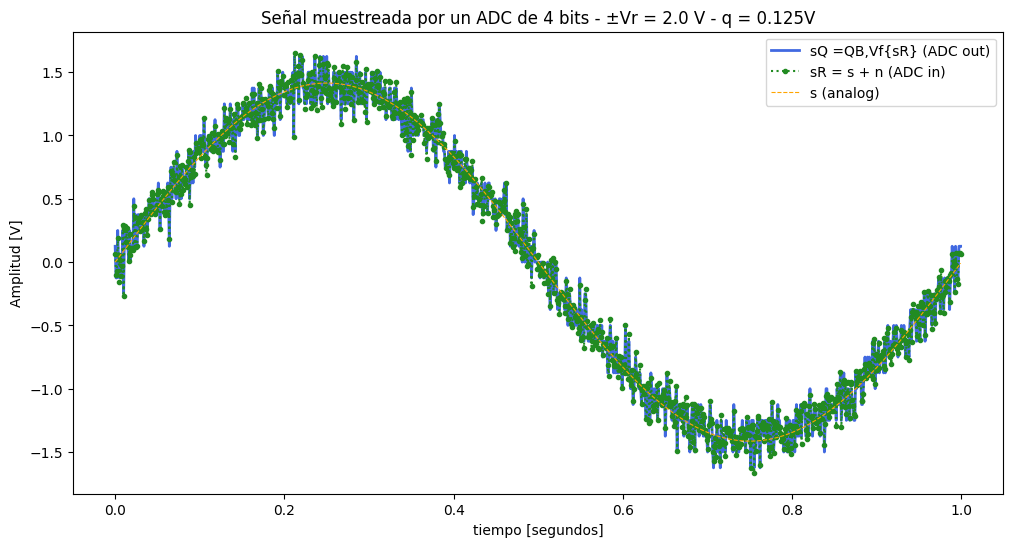

In [10]:
import numpy as np
import matplotlib.pyplot as plt

"vmax: Amplitud maxima , dc: valor medio , ff: frecuencia, ph: fase en radianes , nn: numero de muestras , fs: frecuencia de muestreo" 

fs = 1000
N = 1000

def mi_funcion_sen(vmax, dc , ff , ph , nn , fs):
    
    ts = 1/fs
    tt = np.arange(0, nn, 1)*ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

    return tt, xx 
"tt: vector de tiempo , xx: vector de señal"

tt, xx = mi_funcion_sen(np.sqrt(2) , 0 , fs/N , 0 , N , fs)


vfs = 2
B = 4
kn = 10

q = (vfs) / 2**B
pq = (q**2)/12
Pn = kn*pq

snr_pn = 10 * np.log10(1/Pn)
ruido_pn = np.random.normal(0 , np.sqrt(Pn) , len(tt))

#señal + ruido analogico
xxpn = xx + ruido_pn

# recorte al rango del ADC
xxpn_clip = np.clip(xxpn, -vfs, vfs)

# cuantización
xxq = q * np.round(xxpn_clip / q)

#error
eq = xxq - xxpn_clip

plt.figure(figsize=(12,6))
plt.plot(tt, xxq, color = 'royalblue',label='sQ =QB,Vf{sR} (ADC out)', linewidth = 2)
plt.plot(tt, xxpn, '.:', color = 'forestgreen',label = 'sR = s + n (ADC in)')
plt.plot(tt, xx, '--', color = 'orange', label = 's (analog)', linewidth = 0.8)
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vfs:.1f} V - q = {q:.3f}V')
plt.xlabel("tiempo [segundos]")
plt.ylabel("Amplitud [V]")
plt.legend()
plt.show()

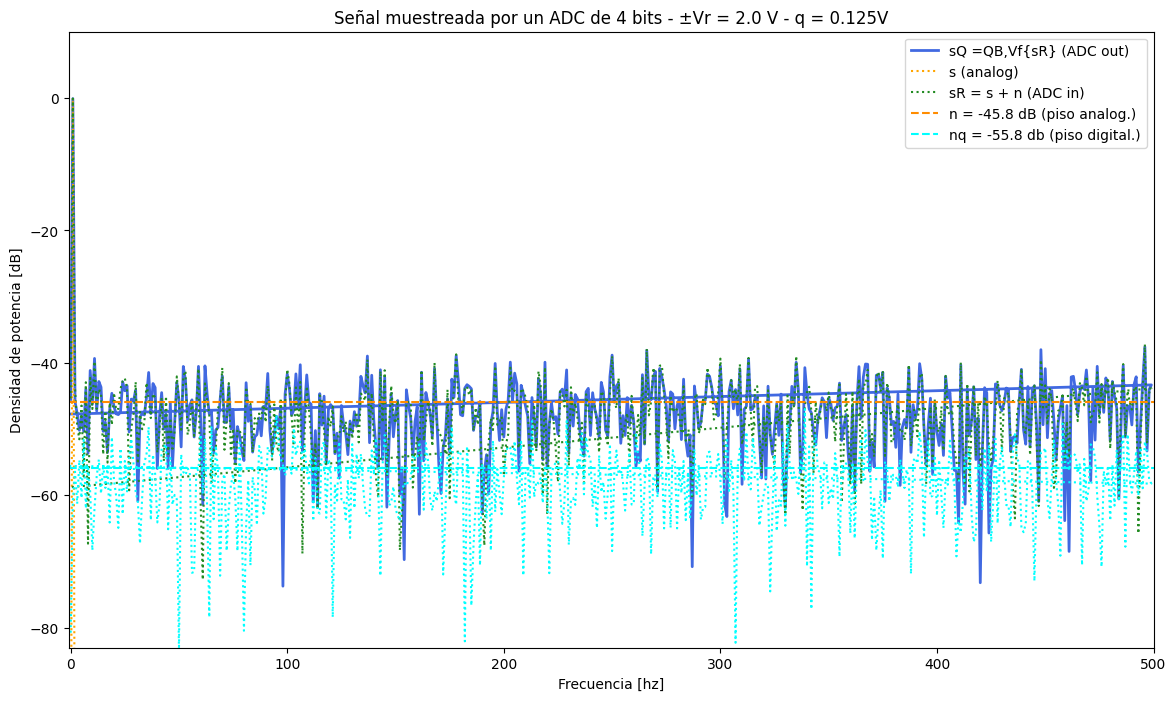

In [11]:

#Espectro de potencia
XX = np.fft.fft(xx)/N
XX_mod = 2 * (np.abs(XX)**2)

XXPn = np.fft.fft(xxpn)/N
XXPn_mod = 2 * (np.abs(XXPn)**2)

XXQ = np.fft.fft(xxq)/N
XXQ_mod = 2 * (np.abs(XXQ)**2)

EQ = np.fft.fft(eq)/N
EQ_mod = 2 * (np.abs(EQ)**2)

#vector de frecuencias
freq = np.fft.fftfreq(len(xx), 1/fs)

# magnitud normalizada en dB
XX_db = 10 * np.log10(XX_mod + 1e-12)
XXPn_db = 10 * np.log10(XXPn_mod + 1e-12)
XXQ_db = 10 * np.log10(XXQ_mod + 1e-12)
EQ_db = 10 * np.log10(EQ_mod + 1e-12)

piso_analog = 10 * np.log10(Pn/(N/2) + 1e-12)
piso_digital = 10 * np.log10(pq/(N/2) + 1e-12)


plt.figure(figsize=(14,8))
plt.ylim(-83, 10)
plt.xlim(-1 , 500)
plt.plot(freq, XXQ_db, color = 'royalblue',label='sQ =QB,Vf{sR} (ADC out)', linewidth = 2)
plt.plot(freq, XX_db, ':', color = 'orange', label = 's (analog)', linewidth = 1.5)
plt.plot(freq, XXPn_db, ':', color = 'forestgreen',label = 'sR = s + n (ADC in)', linewidth = 1.5)
plt.axhline(piso_analog, color = 'darkorange', linestyle='--', label = f'n = {piso_analog:.1f} dB (piso analog.)',linewidth = 1.5)
plt.axhline(piso_digital, color = 'cyan', linestyle='--', label = f'nq = {piso_digital:.1f} db (piso digital.)', linewidth = 1.5)
plt.plot(freq, EQ_db, ':', color='cyan')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±Vr = {vfs:.1f} V - q = {q:.3f}V')
plt.xlabel("Frecuencia [hz]")
plt.ylabel("Densidad de potencia [dB]")
plt.legend()
plt.show()

Aca es donde está el error con las lineas raras

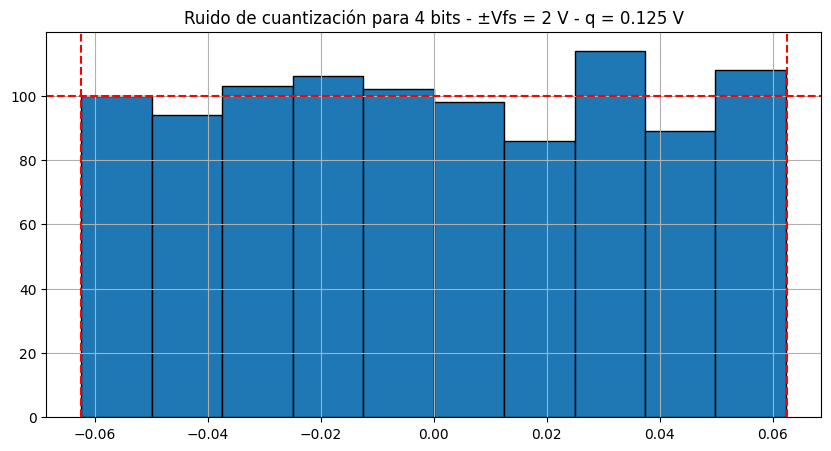

In [12]:
plt.figure(figsize=(10,5))

# histograma y guardo datos
counts, bins, _ = plt.hist(eq, bins=10, edgecolor='black')

# centros de cada barra
centros = 0.5 * (bins[:-1] + bins[1:])

# barras dentro del intervalo [-q/2, q/2]
mask = (centros >= -q/2) & (centros <= q/2)

# media de las alturas en ese intervalo
media_intervalo = np.mean(counts[mask])

# líneas rojas
plt.axvline(-q/2, color='r', linestyle='--')
plt.axvline(q/2, color='r', linestyle='--')
plt.axhline(media_intervalo, color='r', linestyle='--')
plt.title(f'Ruido de cuantización para {B} bits - ±Vfs = {vfs} V - q = {q:.3f} V')
plt.grid(True)
plt.show()